# 01 — RPW exploration (sanity check)

Eyeball the cleaned panel. Not for final results — those live in the pipeline modules.

What this notebook checks:
1. Row counts and dimension cardinalities.
2. Missingness heatmap.
3. Fee / FX margin / total-cost distributions.
4. `days_to_arrive` and speed-penalty composition.
5. Coverage by sending country, receiving country, firm type.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

# Make the pipeline package importable when running from notebooks/.
PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / 'pyproject.toml').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pipeline import config

sns.set_theme(style='whitegrid', context='notebook', palette='deep')
pd.set_option('display.max_rows', 60)
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')


In [2]:
df = pd.read_parquet(config.PROCESSED_RPW_PATH)
print(f'rows: {len(df):,}')
print(f'columns: {list(df.columns)}')
df.head(3)

rows: 391,797
columns: ['period', 'source_code', 'source_name', 'source_region', 'source_income', 'destination_code', 'destination_name', 'destination_region', 'destination_income', 'firm', 'payment_instrument', 'access_point', 'pickup_method', 'pickup_location', 'interbank_fx_rate', 'transparent', 'date', 'year', 'quarter', 'period_dt', 'corridor_id', 'firm_type', 'days_to_arrive', 'speed_penalty_pct', 'lcu_code', 'fx_margin_pct', 'total_cost_pct', 'send_amount_usd', 'fee_pct', 'tci_pct', 'send_amount_bucket_usd']


,period,source_code,source_name,source_region,source_income,destination_code,destination_name,destination_region,destination_income,firm,payment_instrument,access_point,pickup_method,pickup_location,interbank_fx_rate,transparent,date,year,quarter,period_dt,corridor_id,firm_type,days_to_arrive,speed_penalty_pct,lcu_code,fx_margin_pct,total_cost_pct,send_amount_usd,fee_pct,tci_pct,send_amount_bucket_usd
0,2016_2Q,AGO,Angola,Sub-Saharan Africa,Lower middle income,NAM,Namibia,Sub-Saharan Africa,Upper middle income,MoneyGram,Cash,Agent,Cash,Agent,0.0908,yes,2016-05-11,2016,2,2016-04-01,AGO-NAM,MTO,0.0000,0.0000,AOA,7.4900,16.2800,200.0000,8.7900,16.2800,200
1,2016_2Q,AGO,Angola,Sub-Saharan Africa,Lower middle income,NAM,Namibia,Sub-Saharan Africa,Upper middle income,Real Transfer,"Bank account transfer,Cash",Agent,Cash,Agent,0.0908,yes,2016-05-11,2016,2,2016-04-01,AGO-NAM,MTO,0.0000,0.0000,AOA,4.1900,14.1900,200.0000,10.0000,14.1900,200
2,2016_2Q,AGO,Angola,Sub-Saharan Africa,Lower middle income,NAM,Namibia,Sub-Saharan Africa,Upper middle income,Standard Bank,Bank account transfer,Bank branch,Bank account,NaN,1.0000,no,2016-05-11,2016,2,2016-04-01,AGO-NAM,Bank,1.0000,0.0000,AOA,0.0000,27.5000,200.0000,27.5000,27.5000,200


## 1. Cardinalities

In [3]:
card = pd.Series({
    'unique periods': df['period'].nunique(),
    'unique corridors': df['corridor_id'].nunique(),
    'unique sending countries': df['source_code'].nunique(),
    'unique receiving countries': df['destination_code'].nunique(),
    'unique firms': df['firm'].nunique(),
    'unique firm types': df['firm_type'].nunique(),
    'rows USD 200': (df['send_amount_bucket_usd'] == 200).sum(),
    'rows USD 500': (df['send_amount_bucket_usd'] == 500).sum(),
})
card

unique periods                    36
unique corridors                 368
unique sending countries          49
unique receiving countries       105
unique firms                     694
unique firm types                  5
rows USD 200                  196715
rows USD 500                  195082
dtype: int64

## 2. Missingness heatmap

columns with any missingness:
date              81.2100
pickup_location   55.4300


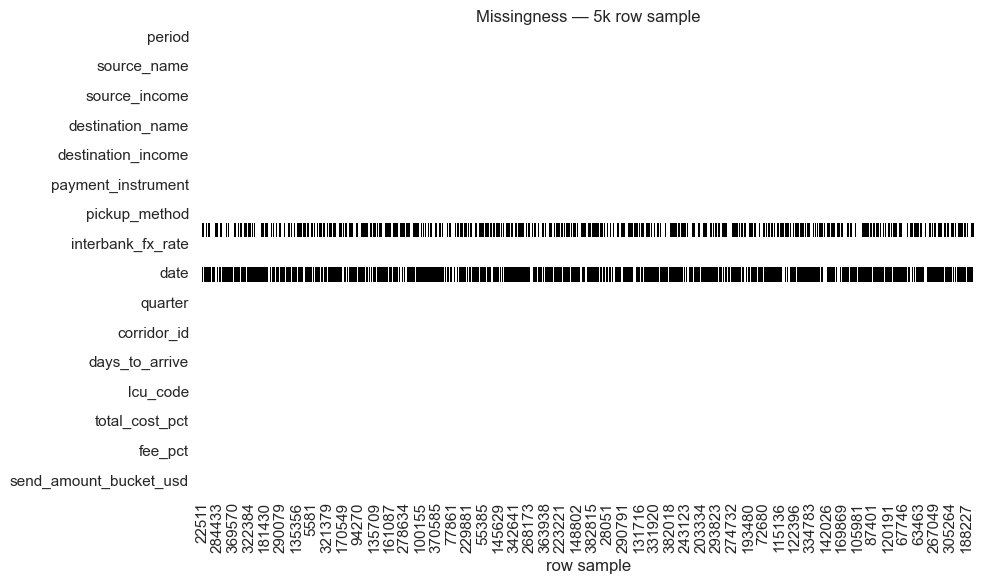

In [4]:
missing = df.isna().mean().sort_values(ascending=False)
missing_pct = missing[missing > 0]
print('columns with any missingness:')
print((missing_pct * 100).round(2).to_string())
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    df.sample(min(5000, len(df)), random_state=1).isna().T,
    cbar=False, cmap='gray_r', ax=ax,
)
ax.set_title('Missingness — 5k row sample')
ax.set_xlabel('row sample')
plt.tight_layout()
plt.show()

## 3. Fee / FX margin / total-cost distributions (USD 200)

           fee_pct  fx_margin_pct  total_cost_pct  speed_penalty_pct  \
count 196,715.0000   196,715.0000    196,715.0000       196,715.0000   
mean        4.4600         2.1700          6.6200             0.0500   
std         4.9200         2.6500          5.6900             0.1100   
min         0.0000       -13.0800          0.0000             0.0000   
25%         1.9700         0.3500          3.1600             0.0000   
50%         3.0000         1.4900          5.0900             0.0000   
75%         5.0000         3.0800          8.2200             0.0000   
max        96.9200        59.9800         99.4300             0.5000   

           tci_pct  
count 196,715.0000  
mean        6.6800  
std         5.7100  
min         0.0000  
25%         3.2100  
50%         5.1500  
75%         8.2600  
max        99.5300  


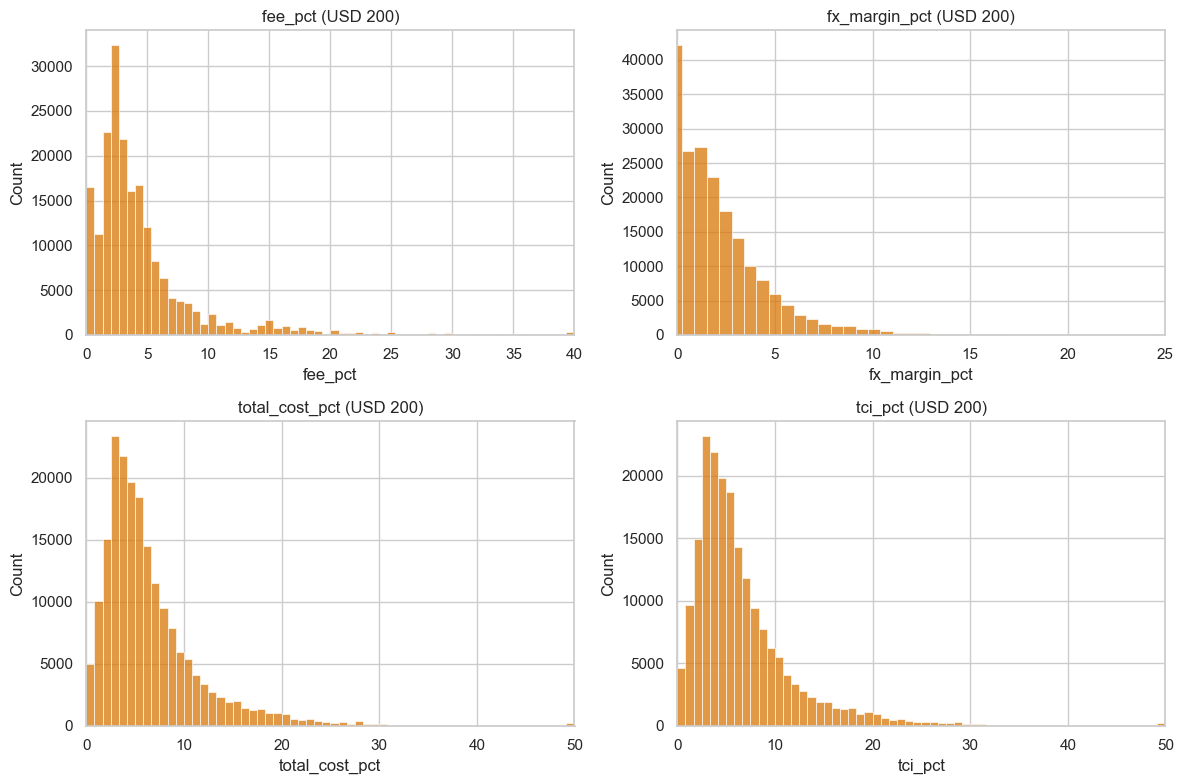

In [5]:
head = df[df['send_amount_bucket_usd'] == 200]
print(head[['fee_pct', 'fx_margin_pct', 'total_cost_pct', 'speed_penalty_pct', 'tci_pct']].describe().round(2))
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col, x_max in zip(axes.flat,
                          ['fee_pct', 'fx_margin_pct', 'total_cost_pct', 'tci_pct'],
                          [40, 25, 50, 50]):
    sns.histplot(head[col].clip(upper=x_max), bins=60, ax=ax, color='#D97706')
    ax.set_title(f'{col} (USD 200)')
    ax.set_xlim(0, x_max)
plt.tight_layout()
plt.show()

## 4. Speed buckets

days_to_arrive
0.0000    124701
1.0000     22901
2.0000     25423
4.0000     21518
6.0000      2172
Name: count, dtype: int64


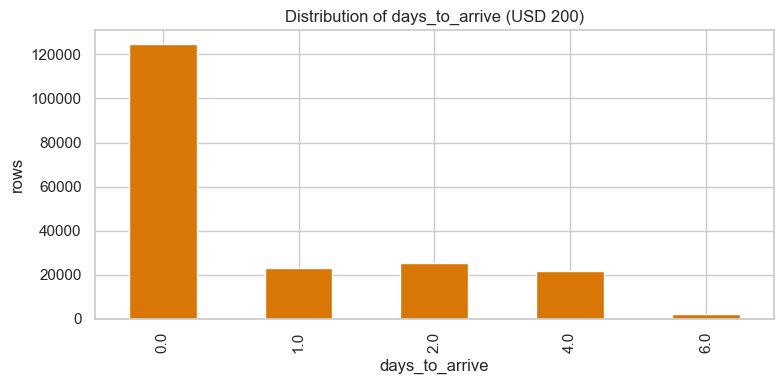

In [6]:
speed = head['days_to_arrive'].value_counts().sort_index()
print(speed)
fig, ax = plt.subplots(figsize=(8, 4))
speed.plot.bar(ax=ax, color='#D97706')
ax.set_title('Distribution of days_to_arrive (USD 200)')
ax.set_ylabel('rows')
plt.tight_layout()
plt.show()

## 5. Firm-type composition

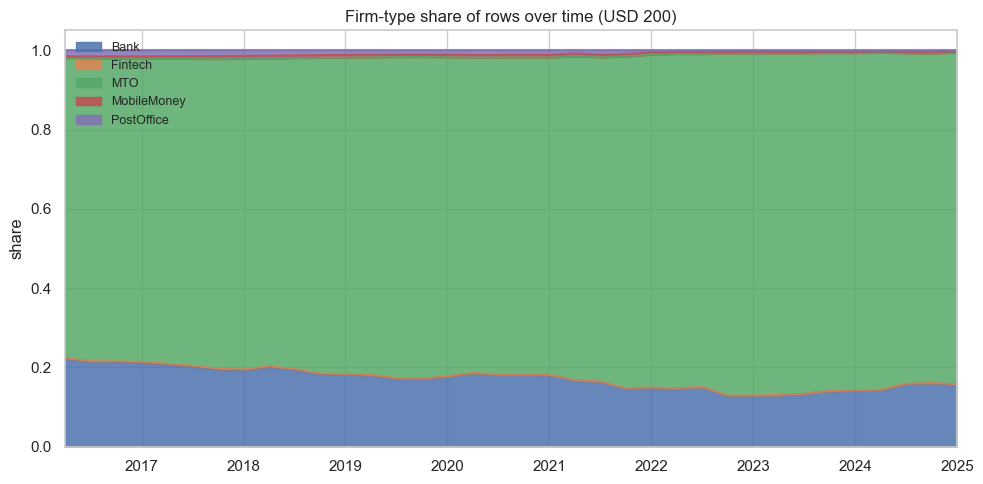

In [7]:
ft = head.groupby(['period_dt', 'firm_type']).size().unstack(fill_value=0)
ft = ft.div(ft.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(10, 5))
ft.plot.area(ax=ax, alpha=0.85)
ax.set_title('Firm-type share of rows over time (USD 200)')
ax.set_ylabel('share')
ax.set_xlabel(None)
ax.legend(loc='upper left', frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

## 6. Top corridors / providers — coverage

In [8]:
latest = head['period_dt'].max()
recent = head[head['period_dt'] == latest]
by_corridor = (recent.groupby('corridor_id')
    .agg(providers=('firm', 'nunique'),
         tci_mean=('tci_pct', 'mean'),
         total_cost_mean=('total_cost_pct', 'mean'))
    .sort_values('total_cost_mean', ascending=False))
print('=== TOP 20 most expensive corridors (USD 200, latest quarter) ===')
print(by_corridor.head(20))
print()
print('=== TOP 20 cheapest corridors (USD 200, latest quarter) ===')
print(by_corridor.tail(20).iloc[::-1])

=== TOP 20 most expensive corridors (USD 200, latest quarter) ===
             providers  tci_mean  total_cost_mean
corridor_id                                      
TZA-UGA              6   63.6250          63.6250
TZA-KEN              7   58.1750          58.1750
TZA-RWA              5   44.2733          44.2733
ZAF-MWI             13   43.4141          43.3487
TUR-BGR              5   41.6986          41.6271
SEN-MLI              5   25.7133          25.6967
ZAF-CHN              5   23.2722          23.2056
SAU-SYR              1   22.1500          22.1500
RWA-KEN              5   17.7186          17.7186
ZAF-AGO              8   16.4573          16.3973
ITA-SRB              7   15.3838          15.3025
ZAF-BWA             11   14.9067          14.8600
ISR-MAR              3   14.1200          14.0200
ZAF-ZMB             13   13.9505          13.9100
ZAF-TZA              7   13.9194          13.8944
ZAF-NGA              9   13.1935          13.1335
THA-IDN              8   12.6359  

In [9]:
by_firm = (head.groupby('firm')
    .agg(corridors=('corridor_id', 'nunique'),
         rows=('tci_pct', 'size'),
         tci_mean=('tci_pct', 'mean'))
    .sort_values('rows', ascending=False))
print('top firms by panel coverage (USD 200):')
by_firm.head(15)

top firms by panel coverage (USD 200):


,corridors,rows,tci_mean
firm,,,
Western Union,360,33542,7.2705
MoneyGram,340,26200,6.4357
Ria,204,12076,5.7870
WorldRemit,223,11448,4.9052
Remitly,142,8084,4.1443
Small World,158,7647,5.7059
Wise,135,3554,3.2015
Azimo,145,3505,5.5053
Xoom,50,3139,5.7973
